# Limpieza de datos: Cafe Sales (Dirty Data for Cleaning Training)

**Actividad 4 - Practica de limpieza de datos**
Isaac Arturo Camarillo Vega - Analisis y Visualizacion de la Informacion (26B)

Dataset: [Cafe Sales - Dirty Data for Cleaning Training](https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training) (Kaggle)

Este notebook carga el archivo `dirty_cafe_sales.csv`, inspecciona los problemas de calidad de datos, aplica tecnicas de limpieza justificadas paso a paso y exporta una version limpia (`cafe_sales_clean.csv`). Al final se construye la tabla resumen de problemas y decisiones que pide la actividad.

## 1. Carga e inspeccion inicial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df_raw = pd.read_csv('dirty_cafe_sales.csv')
print('Filas x columnas:', df_raw.shape)
df_raw.head()

Filas x columnas: (10000, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [2]:
df_raw.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

In [3]:
# Todas las columnas se leyeron como texto (object), incluso las que deberian
# ser numericas o de fecha. Esto ya es un primer indicio de un problema de
# tipos de datos incorrectos.
df_raw.isna().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

Las columnas `Quantity`, `Price Per Unit` y `Total Spent` deberian ser numericas, y `Transaction Date` deberia ser de tipo fecha. Que Pandas las haya leido como texto (`object`) sugiere que contienen valores no numericos mezclados con los numeros.

In [4]:
for col in ['Item', 'Payment Method', 'Location']:
    print(col, '->', df_raw[col].unique())

Item -> <StringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',  'UNKNOWN',
 'Sandwich',        nan,    'ERROR',    'Juice',      'Tea']
Length: 11, dtype: str
Payment Method -> <StringArray>
['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet', 'ERROR', nan]
Length: 6, dtype: str
Location -> <StringArray>
['Takeaway', 'In-store', 'UNKNOWN', nan, 'ERROR']
Length: 5, dtype: str


Aparecen los valores `"ERROR"` y `"UNKNOWN"` en varias columnas, incluidas las categoricas. Estos no son categorias reales del negocio: son marcadores de dato invalido o desconocido que deben tratarse como valores faltantes.

## 2. Identificacion de los problemas de calidad

In [5]:
# Cuantas filas contienen el marcador "ERROR" o "UNKNOWN" en al menos una columna
placeholder_mask = df_raw.isin(['ERROR', 'UNKNOWN'])
print('Filas con ERROR/UNKNOWN en alguna columna:', placeholder_mask.any(axis=1).sum())

# Conteo por columna (ERROR + UNKNOWN + NaN real)
for col in df_raw.columns:
    err = (df_raw[col] == 'ERROR').sum()
    unk = (df_raw[col] == 'UNKNOWN').sum()
    nan = df_raw[col].isna().sum()
    print(f'{col:20s} ERROR={err:5d}  UNKNOWN={unk:5d}  NaN={nan:5d}  total={err+unk+nan:5d}')

Filas con ERROR/UNKNOWN en alguna columna: 2845
Transaction ID       ERROR=    0  UNKNOWN=    0  NaN=    0  total=    0
Item                 ERROR=  292  UNKNOWN=  344  NaN=  333  total=  969
Quantity             ERROR=  170  UNKNOWN=  171  NaN=  138  total=  479
Price Per Unit       ERROR=  190  UNKNOWN=  164  NaN=  179  total=  533
Total Spent          ERROR=  164  UNKNOWN=  165  NaN=  173  total=  502
Payment Method       ERROR=  306  UNKNOWN=  293  NaN= 2579  total= 3178
Location             ERROR=  358  UNKNOWN=  338  NaN= 3265  total= 3961
Transaction Date     ERROR=  142  UNKNOWN=  159  NaN=  159  total=  460


In [6]:
# Duplicados
print('Filas duplicadas exactas:', df_raw.duplicated().sum())
print('Transaction ID duplicados:', df_raw['Transaction ID'].duplicated().sum())

Filas duplicadas exactas: 0
Transaction ID duplicados: 0


No se encontraron filas ni identificadores de transaccion duplicados. Es un resultado valido: se documenta la verificacion aunque no haya nada que eliminar.

In [7]:
# Para revisar valores atipicos y la relacion Total = Quantity x Precio
# hay que convertir primero las columnas numericas (con coercion, tratando
# ERROR/UNKNOWN como NaN).
df_num = df_raw.replace(['ERROR', 'UNKNOWN'], np.nan)
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    df_num[col] = pd.to_numeric(df_num[col], errors='coerce')

df_num[['Quantity', 'Price Per Unit', 'Total Spent']].describe()

,Quantity,Price Per Unit,Total Spent
count,9521.000000,9467.000000,9498.000000
mean,3.028463,2.949984,8.924352
std,1.419007,1.278450,6.009919
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


In [8]:
# Verificar si Total Spent = Quantity x Price Per Unit en las filas donde
# las tres columnas son validas
core = ['Quantity', 'Price Per Unit', 'Total Spent']
mask_all_known = df_num[core].notna().all(axis=1)
calc = df_num.loc[mask_all_known, 'Quantity'] * df_num.loc[mask_all_known, 'Price Per Unit']
discrepancia = (calc - df_num.loc[mask_all_known, 'Total Spent']).abs() > 0.01
print('Filas con las 3 columnas completas:', mask_all_known.sum())
print('Discrepancias Total != Quantity x Precio:', discrepancia.sum())

Filas con las 3 columnas completas: 8544
Discrepancias Total != Quantity x Precio: 0


La relacion se cumple exactamente en las 8,544 filas donde las tres columnas son validas (cero discrepancias). Esto es clave para la limpieza: permite recuperar el valor faltante de una de las tres columnas a partir de las otras dos, de forma determinista y no como una estimacion estadistica.

In [9]:
# Valores atipicos con el rango intercuartilico (IQR)
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    q1, q3 = df_num[col].quantile(0.25), df_num[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_num[col] < lower) | (df_num[col] > upper)).sum()
    print(f'{col:16s} rango valido=[{lower:.2f}, {upper:.2f}]  atipicos={n_out}')

Quantity         rango valido=[-1.00, 7.00]  atipicos=0
Price Per Unit   rango valido=[-1.00, 7.00]  atipicos=0
Total Spent      rango valido=[-8.00, 24.00]  atipicos=259


Valores de Quantity x Precio en los "atipicos" de Total Spent:
      Quantity  Price Per Unit  Total Spent
10         5.0             5.0         25.0
177        NaN             5.0         25.0
874        5.0             NaN         25.0
3779       NaN             NaN         25.0


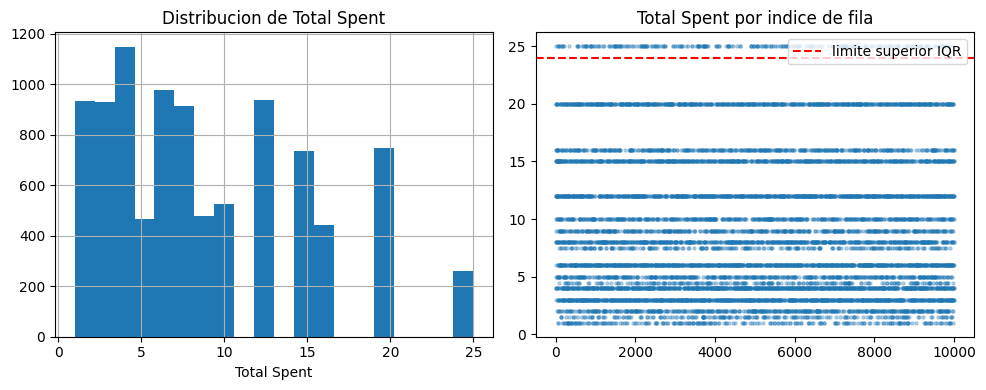

In [10]:
# Inspeccion visual de esos "atipicos" en Total Spent antes de decidir nada
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df_num['Total Spent'].hist(bins=20, ax=ax[0])
ax[0].set_title('Distribucion de Total Spent')
ax[0].set_xlabel('Total Spent')

outliers = df_num[df_num['Total Spent'] > 24]
print('Valores de Quantity x Precio en los "atipicos" de Total Spent:')
print(outliers[['Quantity', 'Price Per Unit', 'Total Spent']].drop_duplicates())
ax[1].scatter(df_num.index, df_num['Total Spent'], s=5, alpha=0.3)
ax[1].axhline(24, color='r', linestyle='--', label='limite superior IQR')
ax[1].set_title('Total Spent por indice de fila')
ax[1].legend()
plt.tight_layout()
plt.show()

El criterio del IQR marca 259 filas de `Total Spent` como "atipicas", pero todas corresponden a `Quantity = 5` x `Price Per Unit = 5.0` = 25, la combinacion mas cara posible del catalogo (una ensalada, el producto mas caro, comprada 5 veces). No es un error de captura: es simplemente el extremo superior de una distribucion que combina un rango pequeno de precios y cantidades. Por eso no se elimina ni se modifica ningun valor en este paso: el IQR senala un candidato a revisar, no una orden automatica de borrado.

## 3. Limpieza y transformacion

### 3.1 Homologar "ERROR" / "UNKNOWN" a NaN y corregir tipos de datos

In [11]:
df = df_raw.copy()
n_total = len(df)

df = df.replace(['ERROR', 'UNKNOWN'], np.nan)
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

df.dtypes

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

### 3.2 Recuperar Quantity / Price Per Unit / Total Spent con la formula `Total = Quantity x Precio`

Se avanza en el orden que va liberando mas informacion: primero el precio (si se conoce el producto y su precio de catalogo), luego el total, luego la cantidad, y por ultimo el precio a partir de total/cantidad para los casos que no se pudieron resolver con el catalogo.

In [12]:
CATALOG_PRICE = {
    'Cookie': 1.0, 'Tea': 1.5, 'Coffee': 2.0, 'Cake': 3.0,
    'Juice': 3.0, 'Sandwich': 4.0, 'Smoothie': 4.0, 'Salad': 5.0,
}

# 1) Precio desde el catalogo cuando el producto es conocido
m1 = df['Price Per Unit'].isna() & df['Item'].notna()
df.loc[m1, 'Price Per Unit'] = df.loc[m1, 'Item'].map(CATALOG_PRICE)

# 2) Total = Quantity x Precio
m2 = df['Total Spent'].isna() & df['Quantity'].notna() & df['Price Per Unit'].notna()
df.loc[m2, 'Total Spent'] = df.loc[m2, 'Quantity'] * df.loc[m2, 'Price Per Unit']

# 3) Quantity = Total / Precio
m3 = df['Quantity'].isna() & df['Total Spent'].notna() & df['Price Per Unit'].notna()
df.loc[m3, 'Quantity'] = (df.loc[m3, 'Total Spent'] / df.loc[m3, 'Price Per Unit']).round()

# 4) Precio = Total / Quantity (para lo que no se resolvio con el catalogo)
m4 = df['Price Per Unit'].isna() & df['Total Spent'].notna() & df['Quantity'].notna()
df.loc[m4, 'Price Per Unit'] = df.loc[m4, 'Total Spent'] / df.loc[m4, 'Quantity']

print('Precio recuperado desde catalogo:', m1.sum())
print('Total recuperado (Qty x Precio):', m2.sum())
print('Quantity recuperado (Total / Precio):', m3.sum())
print('Precio recuperado (Total / Quantity):', m4.sum())

Precio recuperado desde catalogo: 479
Total recuperado (Qty x Precio): 479
Quantity recuperado (Total / Precio): 456
Precio recuperado (Total / Quantity): 48


### 3.3 Item faltante: recuperar solo cuando el precio es inequivoco

El precio identifica de forma unica al producto en cuatro casos (`1.0`->Cookie, `1.5`->Tea, `2.0`->Coffee, `5.0`->Salad). En `3.0` (Cake o Juice) y `4.0` (Sandwich o Smoothie) el precio no alcanza para decidir, asi que esas filas -y las que tampoco tienen precio- se etiquetan como `"Unknown"` en lugar de adivinar.

In [13]:
UNIQUE_PRICE_TO_ITEM = {1.0: 'Cookie', 1.5: 'Tea', 2.0: 'Coffee', 5.0: 'Salad'}

item_missing_before = df['Item'].isna().sum()
recoverable = df['Item'].isna() & df['Price Per Unit'].isin(UNIQUE_PRICE_TO_ITEM.keys())
df.loc[recoverable, 'Item'] = df.loc[recoverable, 'Price Per Unit'].map(UNIQUE_PRICE_TO_ITEM)
n_item_recovered = recoverable.sum()

df['Item'] = df['Item'].fillna('Unknown')
n_item_unknown = (df['Item'] == 'Unknown').sum()

print('Item faltante original:', item_missing_before)
print('Recuperado por precio unico:', n_item_recovered)
print("Marcado como 'Unknown':", n_item_unknown)

Item faltante original: 969
Recuperado por precio unico: 489
Marcado como 'Unknown': 480


### 3.4 Payment Method y Location: no son deducibles de otras columnas

Se conservan las filas (representan 30-40% del total) y se marca el valor como `"Unknown"` en vez de perder toda esa informacion en `Item`, `Quantity`, `Total Spent` y `Transaction Date`.

In [14]:
n_payment_missing = df['Payment Method'].isna().sum()
n_location_missing = df['Location'].isna().sum()
df['Payment Method'] = df['Payment Method'].fillna('Unknown')
df['Location'] = df['Location'].fillna('Unknown')
print('Payment Method marcado como Unknown:', n_payment_missing)
print('Location marcado como Unknown:', n_location_missing)

Payment Method marcado como Unknown: 3178
Location marcado como Unknown: 3961


### 3.5 Transaction Date invalida: se elimina (no se puede reconstruir)

Representa un 4.6% del total. Al no poder deducirse de ninguna otra columna y ser una fraccion pequena, se retiran esas filas del dataset final en vez de dejar fechas invalidas que romperian cualquier analisis por mes o dia.

In [15]:
n_date_invalid = df['Transaction Date'].isna().sum()
df = df.dropna(subset=['Transaction Date'])
print('Filas eliminadas por fecha invalida/faltante:', n_date_invalid)

Filas eliminadas por fecha invalida/faltante: 460


### 3.6 Duplicados (verificacion final) y tipos finales

In [16]:
print('Duplicados exactos restantes:', df.duplicated().sum())

df['Quantity'] = df['Quantity'].astype('Int64')
df['Item'] = df['Item'].astype('category')
df['Payment Method'] = df['Payment Method'].astype('category')
df['Location'] = df['Location'].astype('category')

still_incomplete = df[['Quantity', 'Price Per Unit', 'Total Spent']].isna().any(axis=1).sum()
print('Filas que siguen con algun dato numerico incompleto (no se pudo recuperar):', still_incomplete)
print()
print('Filas iniciales:', n_total, '-> Filas finales:', len(df))
df.info()

Duplicados exactos restantes: 0
Filas que siguen con algun dato numerico incompleto (no se pudo recuperar): 26

Filas iniciales: 10000 -> Filas finales: 9540
<class 'pandas.DataFrame'>
Index: 9540 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9540 non-null   str           
 1   Item              9540 non-null   category      
 2   Quantity          9517 non-null   Int64         
 3   Price Per Unit    9534 non-null   float64       
 4   Total Spent       9517 non-null   float64       
 5   Payment Method    9540 non-null   category      
 6   Location          9540 non-null   category      
 7   Transaction Date  9540 non-null   datetime64[us]
dtypes: Int64(1), category(3), datetime64[us](1), float64(2), str(1)
memory usage: 484.6 KB


## 4. Verificacion final

In [17]:
df.isna().sum()

Transaction ID       0
Item                 0
Quantity            23
Price Per Unit       6
Total Spent         23
Payment Method       0
Location             0
Transaction Date     0
dtype: int64

In [18]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Transaction ID,9540,9540,TXN_1961373,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item,9540,9,Coffee,1246,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,9517.0,<NA>,<NA>,<NA>,3.02133,1.0,2.0,3.0,4.0,5.0,1.42017
Price Per Unit,9534.0,NaN,NaN,NaN,2.948605,1.0,2.0,3.0,4.0,5.0,1.279117
Total Spent,9517.0,NaN,NaN,NaN,8.923243,1.0,4.0,8.0,12.0,25.0,6.006198
Payment Method,9540,4,Unknown,3015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,9540,3,Unknown,3779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction Date,9540,NaN,NaN,NaN,2023-07-01 23:00:31.698113,2023-01-01 00:00:00,2023-04-01 00:00:00,2023-07-02 00:00:00,2023-10-02 00:00:00,2023-12-31 00:00:00,NaN


## 5. Exportar la base limpia

In [19]:
df.to_csv('cafe_sales_clean.csv', index=False)
print('Exportado: cafe_sales_clean.csv')
df.head()

Exportado: cafe_sales_clean.csv


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


## 6. Tabla resumen de problemas y decisiones

| Problema encontrado | Registros afectados | Accion realizada | Justificacion |
|---|---|---|---|
| Valores no permitidos ("ERROR" / "UNKNOWN") en cualquier columna | 2,845 filas | Se homologaron a `NaN` con `df.replace(['ERROR','UNKNOWN'], np.nan)` | No son categorias reales, sino marcadores de dato invalido; tratarlos como texto valido distorsionaria conteos y calculos |
| Tipos de datos incorrectos (`Quantity`, `Price Per Unit`, `Total Spent`, `Transaction Date` leidos como texto) | 10,000 filas (toda la columna) | Conversion con `pd.to_numeric(errors='coerce')` y `pd.to_datetime(errors='coerce')` | Sin el tipo correcto no se pueden hacer operaciones aritmeticas ni de fecha; la coercion evita que el proceso truene y deja como NaN solo lo que ya era invalido |
| `Quantity` / `Price Per Unit` / `Total Spent` faltantes | 1,456 filas (1,430 recuperadas por completo, 26 quedan parcialmente incompletas) | Se recuperaron con la relacion `Total = Quantity x Precio`, usando el precio de catalogo cuando hacia falta | La formula se verifico sin excepciones en 8,544 filas completas, asi que la recuperacion es un calculo exacto, no una estimacion |
| `Item` faltante | 969 filas | 489 recuperadas por precio unico (1.0, 1.5, 2.0 o 5.0); 480 marcadas como `Unknown` | El precio no identifica un producto unico cuando vale 3.0 (Cake o Juice) o 4.0 (Sandwich o Smoothie); adivinar entre ellos inventaria informacion que el dataset no respalda |
| `Payment Method` faltante | 3,178 filas | Se sustituyo por la categoria `Unknown` | Eliminar esas filas descartaria ~32% del dataset y perderia informacion valida en las demas columnas |
| `Location` faltante | 3,961 filas | Se sustituyo por la categoria `Unknown` | Mismo razonamiento que en `Payment Method`: ~40% de filas es demasiado para eliminar por un solo campo no critico |
| Duplicados (filas exactas y `Transaction ID`) | 0 filas | Se verifico con `duplicated()`; no se elimino nada | El dataset no contenia duplicados; se documenta la verificacion en lugar de aplicar `drop_duplicates()` a ciegas |
| Valores atipicos en `Total Spent` (criterio IQR) | 259 filas senaladas por el IQR | No se modificaron ni eliminaron | Corresponden exactamente a `Quantity=5 x Precio=5=25`, la combinacion mas cara valida del catalogo; eliminarlas habria borrado ventas reales, no errores |
| `Transaction Date` invalida o faltante | 460 filas (4.6%) | Se eliminaron del dataset final | La fecha no se puede reconstruir a partir de otras columnas; es una fraccion pequena y su ausencia rompe cualquier analisis por periodo |

**Filas iniciales:** 10,000 &nbsp;&nbsp; **Filas en la base limpia:** 9,540

## 7. Conclusion

La mayoria de los problemas de este dataset no eran errores de medicion, sino marcadores de dato faltante disfrazados de texto ("ERROR", "UNKNOWN"). Una vez homologados a `NaN`, la relacion exacta `Total = Quantity x Precio` permitio recuperar buena parte de la informacion sin inventar nada. Los casos realmente irrecuperables (`Item` ambiguo, `Transaction Date` invalida) se documentaron y, segun el costo de eliminarlos, se dejaron como `Unknown` o se retiraron del dataset final. Los "atipicos" que senalo el IQR en `Total Spent` resultaron ser ventas validas, no errores, lo que confirma que un criterio estadistico automatico no reemplaza la revision del contexto de los datos.